<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/SVD/regional_newWellDeclinecurvePmax_normalized4RecentWells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading Files

You can upload files from your local file system to the Colab environment using the `files.upload()` function from `google.colab`.

In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving SampleWellDeclines.xlsx to SampleWellDeclines.xlsx
User uploaded file "SampleWellDeclines.xlsx" with length 20024 bytes


### Reviewing the Uploaded File

To inspect the contents of the uploaded Excel file, we can load it into a pandas DataFrame. Since `SampleWellDeclines.xlsx` is an Excel file, we'll use `pd.read_excel()`.

In [2]:
import pandas as pd

# Loading the newly uploaded Excel file
df = pd.read_excel('SampleWellDeclines.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,WellID,M0,M1,M2,M3,M4,M5,M6,M7,M8,...,M27,M28,M29,M30,M31,M32,M33,M34,M35,M36
0,A1,155.0,898.0,1122.0,950,797,667.0,480,78,78,...,165.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A2,44.0,339.0,485.0,600,640,599.0,569,493,450,...,103.0,225.0,237.0,165.0,181.0,147.0,148.0,137.0,129.0,61.0
2,A3,129.0,346.0,461.0,422,380,356.0,295,209,254,...,174.0,198.0,173.0,131.0,152.0,135.0,138.0,130.0,135.0,117.0
3,A4,574.0,NaN,598.0,149,444,527.0,436,511,306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A5,43.0,362.0,NaN,493,200,296.0,502,375,280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Creating a Representative Well Production Profile using Weighted SVD

To create a representative well production profile, we will follow these steps:
1.  **Identify Production Data**: Extract the columns representing monthly production (`M0` to `M36`).
2.  **Calculate 'Newness' Weights**: Assign a weight to each well. Wells with more `NaN` values (indicating shorter production history) will receive higher weights.
3.  **Handle Missing Values**: Fill `NaN` values in the production data with `0`, assuming that unrecorded months have zero production.
4.  **Scale the Data**: Standardize the production data to ensure that all months contribute equally to the SVD, regardless of their magnitude.
5.  **Apply Weights**: Multiply each row of the scaled production data by its assigned 'newness' weight.
6.  **Perform SVD**: Apply SVD to the weighted, scaled production matrix.
7.  **Extract Representative Profile**: The first principal component (first right singular vector) from the SVD will represent the dominant production decline pattern.
8.  **Rescale Profile**: Transform the extracted profile back to the original production units for interpretability and ensure all values are non-negative.

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Identify production columns (M0 to M36)
production_cols = [f'M{i}' for i in range(37)]
production_df = df[production_cols]

# 2. Calculate 'Newness' weights
# A well is 'newer' if it has fewer recorded production months (more NaNs at the end).
# We want to give higher weights to wells with more NaNs.
nan_counts = production_df.isna().sum(axis=1)

# Simple weighting: more NaNs = higher weight. Add 1 to ensure minimum weight is 1.
weights = nan_counts + 1

# Normalize weights to avoid extreme values, while preserving relative differences
weights = weights / weights.sum() * len(df) # Scale to keep sum of weights approximately equal to number of wells.

# 3. Handle Missing Values: Fill NaNs with 0 for SVD
# This assumes unproduced months have 0 output.
production_filled = production_df.fillna(0)

# 4. Scale the data using StandardScaler
# Fit scaler on the *unweighted* data to get correct mean/std for inverse transform.
scaler = StandardScaler()
production_scaled = scaler.fit_transform(production_filled)

# 5. Apply row-wise weighting to the scaled data
# Convert weights Series to a NumPy array before reshaping
weighted_production_scaled = production_scaled * weights.to_numpy()[:, np.newaxis]

# 6. Perform SVD on the weighted and scaled data
U, s, Vt = np.linalg.svd(weighted_production_scaled, full_matrices=False)

# 7. Extract the first principal component as the representative profile
# The first row of Vt contains the components of the first principal component.
representative_profile_scaled = Vt[0, :]

# 8. Inverse transform to original scale and ensure non-negativity
# We use the mean and std dev from the original, unweighted data to inverse transform.
representative_profile = representative_profile_scaled * scaler.scale_ + scaler.mean_

# Production values cannot be negative, so clip any negative values to 0
representative_profile[representative_profile < 0] = 0

# Convert to a DataFrame for better display
representative_df = pd.DataFrame(
    representative_profile,
    index=production_cols,
    columns=['Representative Production (Weighted SVD)']
)

print("Representative Well Production Profile (Weighted SVD):")
display(representative_df)

Representative Well Production Profile (Weighted SVD):


,Representative Production (Weighted SVD)
M0,657.407062
M1,2055.237951
M2,1887.936096
M3,1626.743859
M4,1437.812169
M5,1227.931020
M6,1085.833538
M7,942.324854
M8,896.149430
M9,810.739823


This `representative_df` now shows the average production profile across the 37 months, with newer wells having a greater influence on its shape. This profile can be used as a template for modeling future well production.

### Comparing Representative Profile with an Individual Well's Production

To understand how well the generated representative profile reflects individual well behavior, let's plot it against the production data of a single well. We will use `WellID A1` for this comparison.

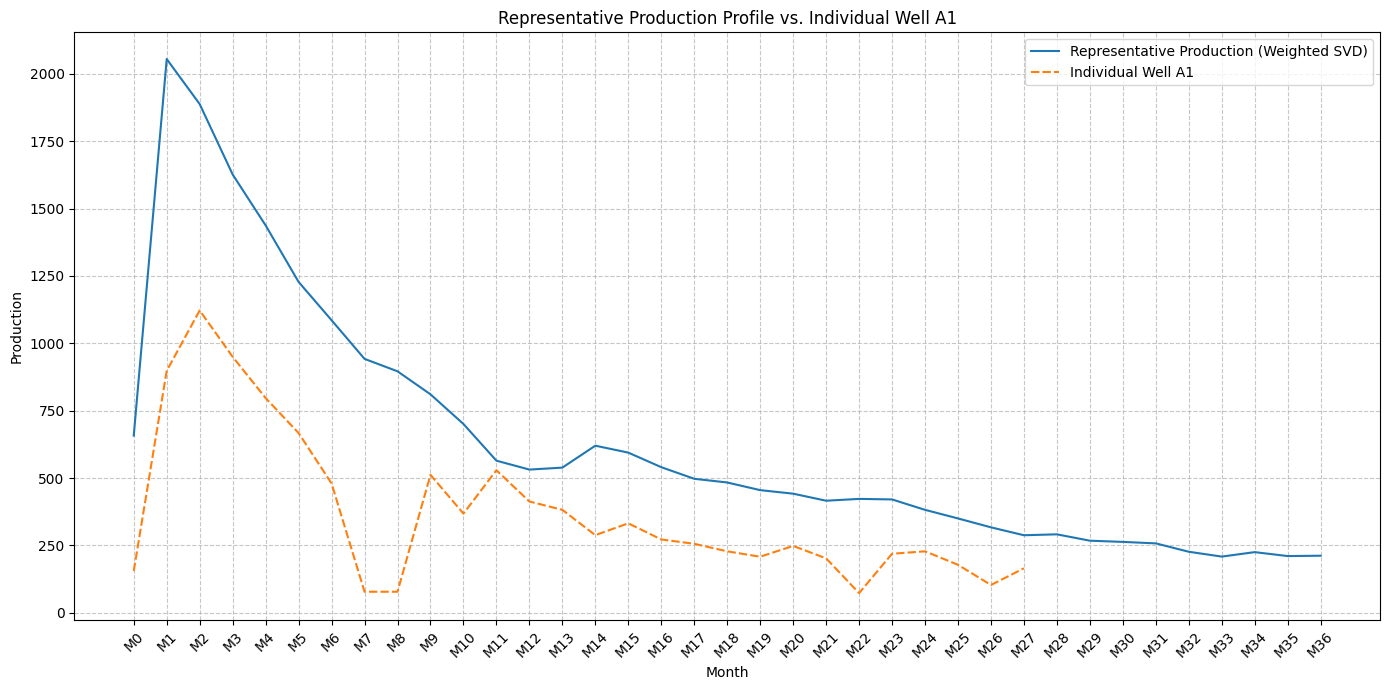

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select an individual well (e.g., WellID A1)
individual_well_id = 'A1'
individual_well_data = df[df['WellID'] == individual_well_id][production_cols].iloc[0]

# Convert to a DataFrame for plotting, aligning with representative_df structure
individual_well_df = pd.DataFrame(
    individual_well_data.values,
    index=production_cols,
    columns=[f'Individual Well {individual_well_id}']
)

# Combine the representative profile and the individual well's data for plotting
comparison_df = pd.concat([representative_df, individual_well_df], axis=1)

plt.figure(figsize=(14, 7))
sns.lineplot(data=comparison_df)
plt.title(f'Representative Production Profile vs. Individual Well {individual_well_id}')
plt.xlabel('Month')
plt.ylabel('Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot visually demonstrates how the representative profile (derived from weighted SVD) compares to the actual production of a specific well. It helps in assessing whether the representative profile captures the general decline trend of wells in the region, while also highlighting individual well variations.

### Visualizing All Individual Wells with the Representative Profile

This visualization will show all individual well production profiles (in light gray) along with the representative profile (in a contrasting color). This helps to see the variability among individual wells and how well the representative profile captures the overall trend.

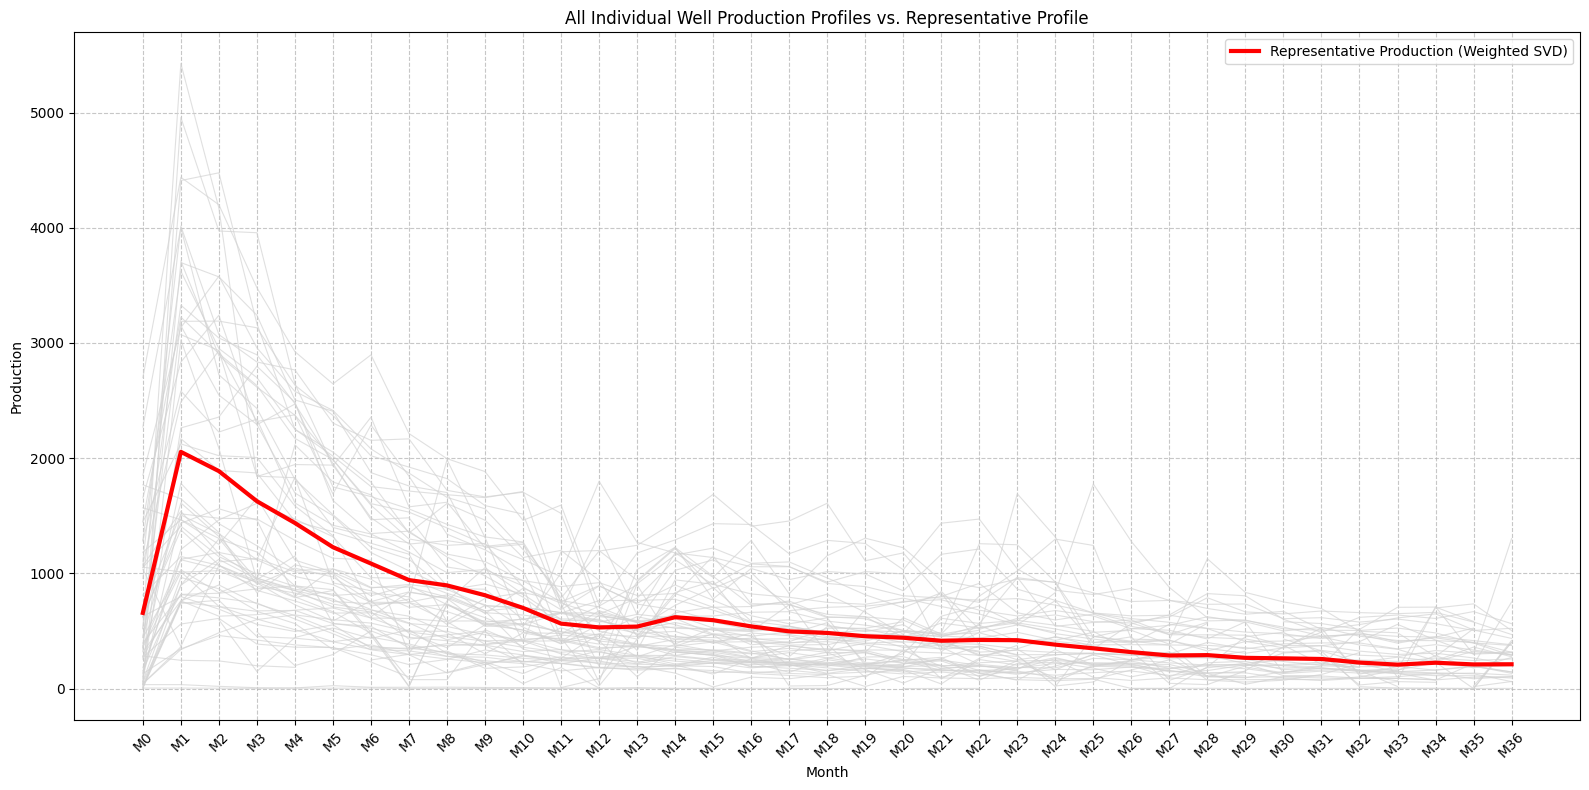

In [5]:
plt.figure(figsize=(16, 8))

# Plot all individual wells in a light grey color
for index, row in df.iterrows():
    plt.plot(production_cols, row[production_cols].values, color='lightgray', alpha=0.7, linewidth=0.8)

# Plot the representative profile with a distinct color and thicker line
plt.plot(
    representative_df.index,
    representative_df['Representative Production (Weighted SVD)'],
    color='red',
    linewidth=3,
    label='Representative Production (Weighted SVD)'
)

plt.title('All Individual Well Production Profiles vs. Representative Profile')
plt.xlabel('Month')
plt.ylabel('Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Refining the Decline Curve Fit: Excluding M0 and Adjusting for Partial Month

As M0 often represents a partial production month and can distort the overall decline trend, we will refine the curve fitting process. We will:

1.  **Exclude M0 from the fitting**: Perform `curve_fit` using data from M1 onwards.
2.  **Estimate M0**: Once the curve is fitted, we will estimate the production for M0 as approximately half of the fitted M1 production, reflecting its nature as a partial month.
3.  **Plot the new fit**: Visualize this adjusted fitted curve against the original representative profile.

Refined Fitted Parameters (M1 onwards): A=2080.96, B=0.1474, C=268.14


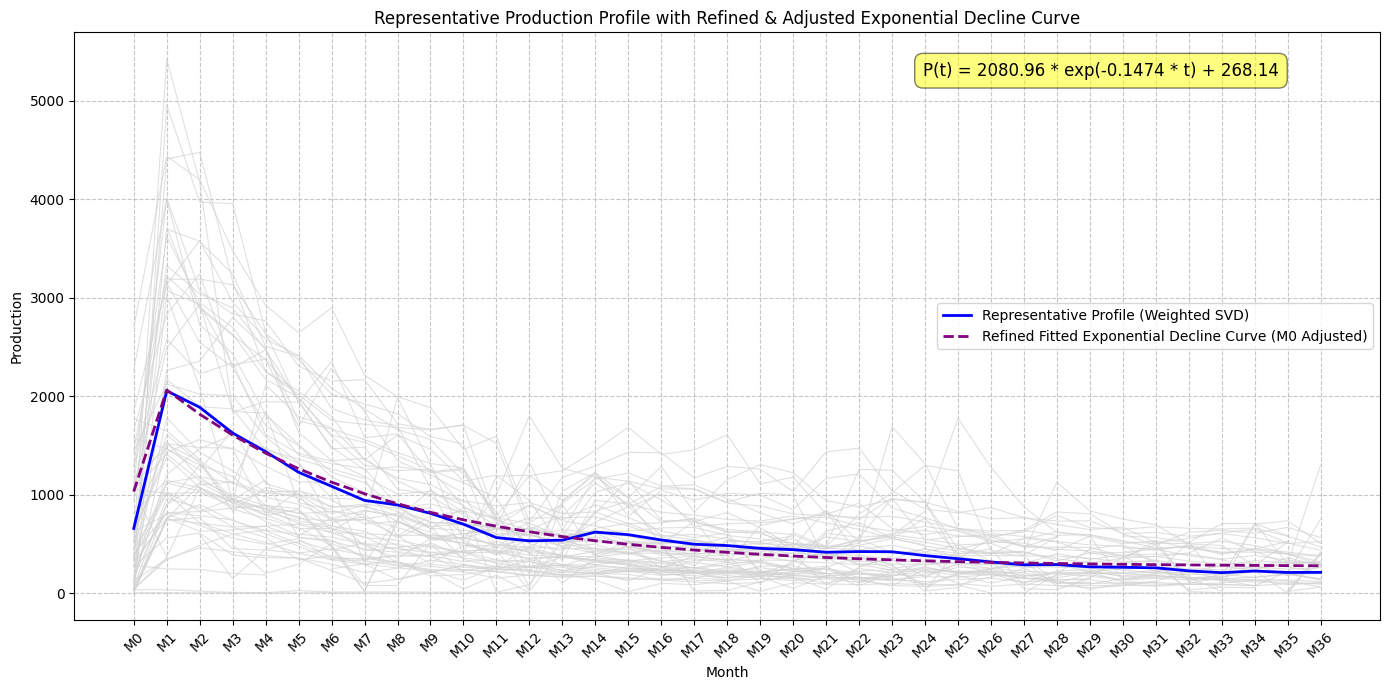

In [6]:
from scipy.optimize import curve_fit

# Define the exponential decline function
def exponential_decline(t, A, B, C):
    return A * np.exp(-B * t) + C


# Prepare data for fitting, excluding M0
x_data_refined = np.arange(1, len(representative_df)) # Months from 1 to 36
y_data_refined = representative_df['Representative Production (Weighted SVD)'].iloc[1:].values

# Initial guess for the parameters (A, B, C) for the refined data
# Use M1 production for A
initial_guess_refined = [y_data_refined[0], 0.1, y_data_refined[-1]]

# Perform the curve fitting on the refined data (M1 to M36)
try:
    params_refined, covariance_refined = curve_fit(exponential_decline, x_data_refined, y_data_refined, p0=initial_guess_refined, maxfev=5000)
    A_fit_refined, B_fit_refined, C_fit_refined = params_refined

    print(f"Refined Fitted Parameters (M1 onwards): A={A_fit_refined:.2f}, B={B_fit_refined:.4f}, C={C_fit_refined:.2f}")

    # Generate the fitted curve data for M1 to M36
    fitted_curve_data_refined = exponential_decline(x_data_refined, A_fit_refined, B_fit_refined, C_fit_refined)

    # Estimate M0 as approximately half of the fitted M1 production
    # The first element of fitted_curve_data_refined corresponds to M1 (x_data_refined[0])
    m0_estimated = fitted_curve_data_refined[0] / 2

    # Combine M0 estimated with the rest of the refined fitted data
    full_fitted_curve = np.insert(fitted_curve_data_refined, 0, m0_estimated)

    # Plot the original representative profile and the new, refined fitted curve
    plt.figure(figsize=(14, 7))

    # Plot all individual wells in a light grey color
    for index, row in df.iterrows():
        plt.plot(production_cols, row[production_cols].values, color='lightgray', alpha=0.7, linewidth=0.8)

    sns.lineplot(x=representative_df.index, y=representative_df['Representative Production (Weighted SVD)'], label='Representative Profile (Weighted SVD)', color='blue', linewidth=2)
    sns.lineplot(x=representative_df.index, y=full_fitted_curve, label='Refined Fitted Exponential Decline Curve (M0 Adjusted)', color='purple', linestyle='--', linewidth=2)

    plt.title('Representative Production Profile with Refined & Adjusted Exponential Decline Curve')
    plt.xlabel('Month')
    plt.ylabel('Production')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()

    # Add equation and parameters to the plot
    equation_text = f"P(t) = {A_fit_refined:.2f} * exp(-{B_fit_refined:.4f} * t) + {C_fit_refined:.2f}"
    plt.text(0.65, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting refined curve: {e}. Check initial guess or data.")

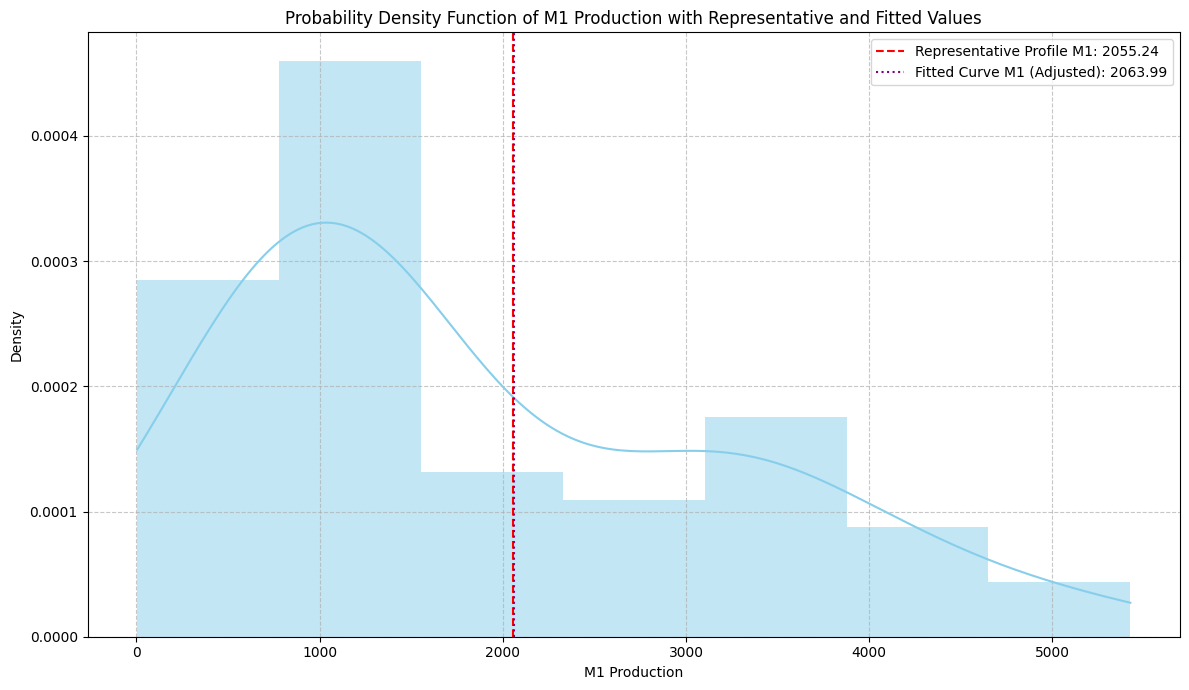

In [7]:
plt.figure(figsize=(12, 7))
sns.histplot(df['M1'].dropna(), kde=True, color='skyblue', stat='density', linewidth=0)

# Get M1 value from representative_df
m1_representative = representative_df.loc['M1', 'Representative Production (Weighted SVD)']
plt.axvline(m1_representative, color='red', linestyle='--', label=f'Representative Profile M1: {m1_representative:.2f}')

# Get M1 value from full_fitted_curve
# The M1 index in representative_df corresponds to index 1 in full_fitted_curve
m1_fitted = full_fitted_curve[1]
plt.axvline(m1_fitted, color='purple', linestyle=':', label=f'Fitted Curve M1 (Adjusted): {m1_fitted:.2f}')

plt.title('Probability Density Function of M1 Production with Representative and Fitted Values')
plt.xlabel('M1 Production')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

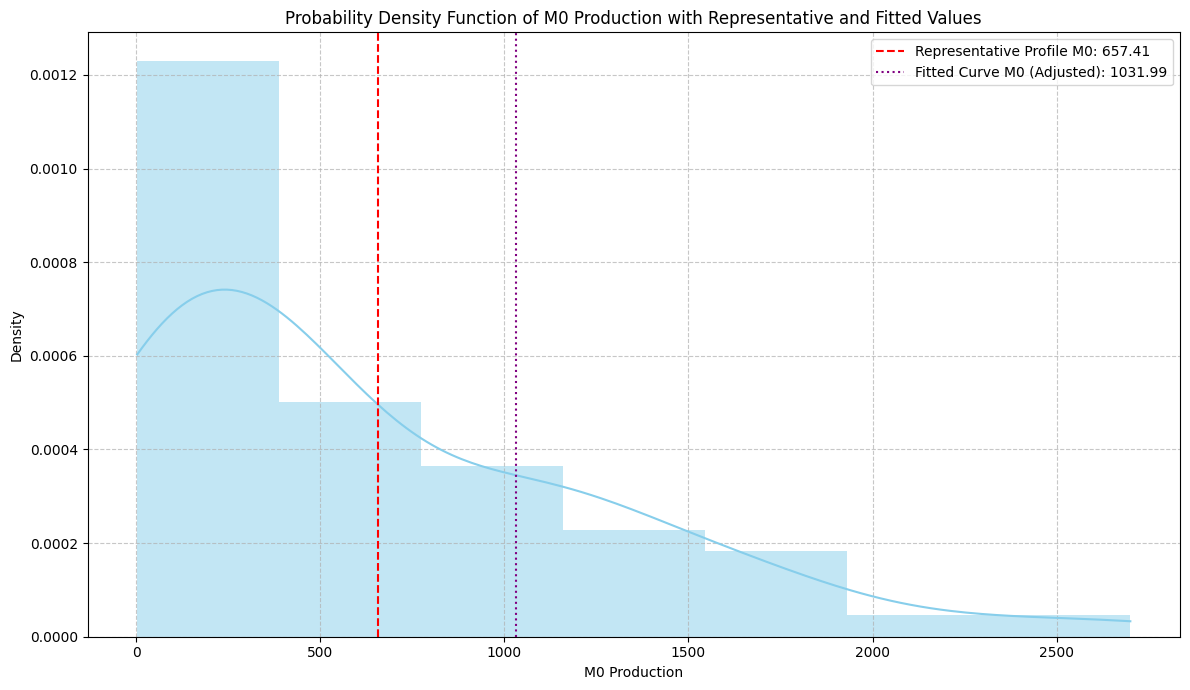

In [8]:
plt.figure(figsize=(12, 7))
sns.histplot(df['M0'].dropna(), kde=True, color='skyblue', stat='density', linewidth=0)

# Get M0 value from representative_df
m0_representative = representative_df.loc['M0', 'Representative Production (Weighted SVD)']
plt.axvline(m0_representative, color='red', linestyle='--', label=f'Representative Profile M0: {m0_representative:.2f}')

# Get M0 value from full_fitted_curve
# The M0 index in representative_df corresponds to index 0 in full_fitted_curve
m0_fitted = full_fitted_curve[0]
plt.axvline(m0_fitted, color='purple', linestyle=':', label=f'Fitted Curve M0 (Adjusted): {m0_fitted:.2f}')

plt.title('Probability Density Function of M0 Production with Representative and Fitted Values')
plt.xlabel('M0 Production')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Normalizing Production Data and Recalculating Representative Profile with Weighted SVD

We will now normalize each well's production data by its maximum production value. This helps in comparing decline trends without the influence of initial production magnitudes. After normalization, we will re-apply the weighted SVD process.

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Identify production columns (M0 to M36)
# (Reusing production_cols from previous context)

# Keep track of original highest production values for later use
highest_production_per_well = df[production_cols].max(axis=1)

# 2. Normalize production data for each well by its highest production value
# This creates a normalized production DataFrame where each row is scaled by its max
production_df_normalized = df[production_cols].div(highest_production_per_well, axis=0)

# 3. Handle Missing Values: Fill NaNs with 0 for SVD
# This assumes unproduced months have 0 output after normalization
production_filled_normalized = production_df_normalized.fillna(0)

# Re-use the existing 'newness' weights calculated earlier
# (weights based on nan_counts from the original, unnormalized production data)

# 4. Scale the normalized data using StandardScaler
# Fit scaler on the *unweighted* normalized data to get correct mean/std for inverse transform.
scaler_normalized = StandardScaler()
production_scaled_normalized = scaler_normalized.fit_transform(production_filled_normalized)

# 5. Apply row-wise weighting to the scaled normalized data
# Convert weights Series to a NumPy array before reshaping
weighted_production_scaled_normalized = production_scaled_normalized * weights.to_numpy()[:, np.newaxis]

# 6. Perform SVD on the weighted and scaled normalized data
U_norm, s_norm, Vt_norm = np.linalg.svd(weighted_production_scaled_normalized, full_matrices=False)

# 7. Extract the first principal component as the representative profile
# The first row of Vt_norm contains the components of the first principal component.
representative_profile_scaled_normalized = Vt_norm[0, :]

# 8. Inverse transform to original scale (normalized context) and ensure non-negativity
# We use the mean and std dev from the original, unweighted normalized data to inverse transform.
representative_profile_normalized = representative_profile_scaled_normalized * scaler_normalized.scale_ + scaler_normalized.mean_

# Production values cannot be negative, so clip any negative values to 0
representative_profile_normalized[representative_profile_normalized < 0] = 0

# Convert to a DataFrame for better display
representative_df_normalized = pd.DataFrame(
    representative_profile_normalized,
    index=production_cols,
    columns=['Normalized Representative Production (Weighted SVD)']
)

print("Normalized Representative Well Production Profile (Weighted SVD):")
display(representative_df_normalized)


Normalized Representative Well Production Profile (Weighted SVD):


,Normalized Representative Production (Weighted SVD)
M0,0.401476
M1,0.914491
M2,0.860040
M3,0.742317
M4,0.666589
M5,0.604842
M6,0.530458
M7,0.441345
M8,0.414035
M9,0.391050


### Refining the Decline Curve Fit for Normalized Data

Now, we will fit the exponential decline function to this *normalized* representative profile, again excluding M0 and adjusting its estimate after fitting.

Refined Fitted Parameters (Normalized M1 onwards): A=0.95, B=0.1119, C=0.06


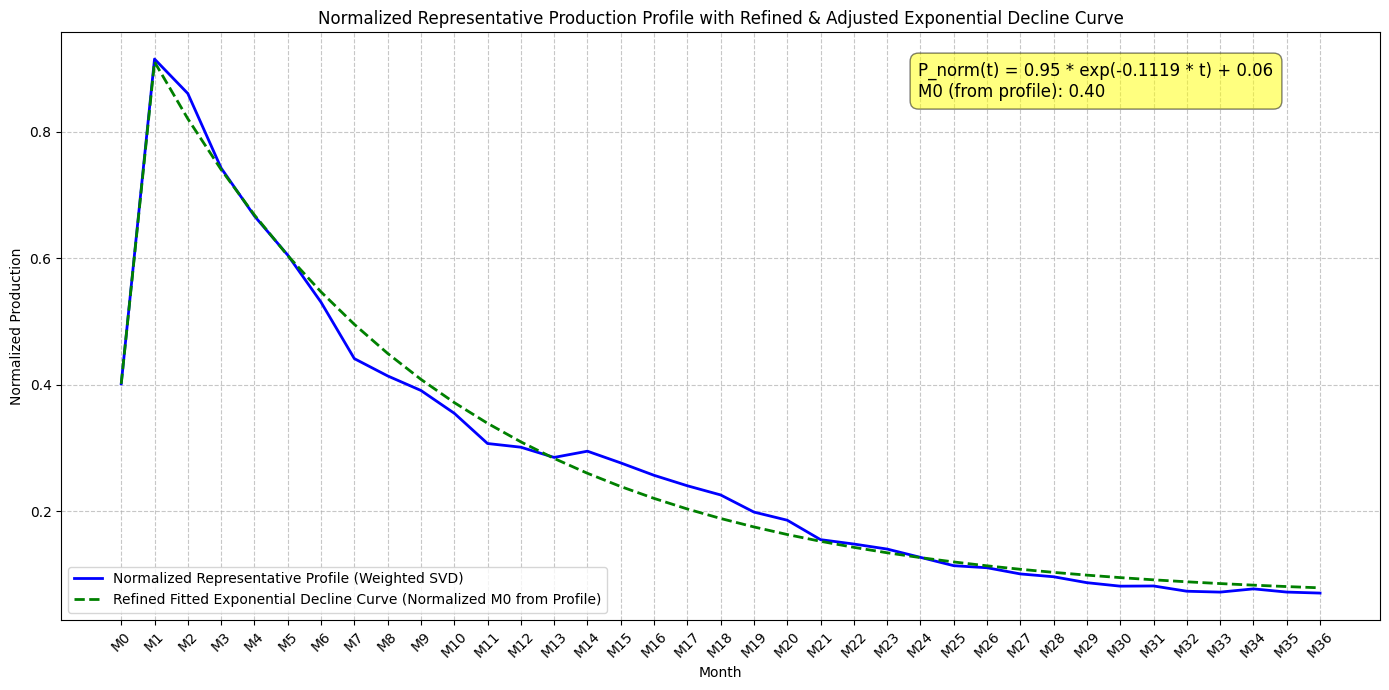

In [10]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

# Define the exponential decline function (same as before)
def exponential_decline(t, A, B, C):
    return A * np.exp(-B * t) + C

# Prepare data for fitting, excluding M0 from the normalized representative profile
x_data_refined_normalized = np.arange(1, len(representative_df_normalized)) # Months from 1 to 36
y_data_refined_normalized = representative_df_normalized['Normalized Representative Production (Weighted SVD)'].iloc[1:].values

# Initial guess for the parameters (A, B, C) for the refined normalized data
# Use M1 normalized production for A
initial_guess_refined_normalized = [y_data_refined_normalized[0], 0.1, y_data_refined_normalized[-1]]

# Perform the curve fitting on the refined normalized data (M1 to M36)
try:
    params_refined_normalized, covariance_refined_normalized = curve_fit(
        exponential_decline, x_data_refined_normalized, y_data_refined_normalized,
        p0=initial_guess_refined_normalized, maxfev=5000
    )
    A_fit_refined_normalized, B_fit_refined_normalized, C_fit_refined_normalized = params_refined_normalized

    print(f"Refined Fitted Parameters (Normalized M1 onwards): A={A_fit_refined_normalized:.2f}, B={B_fit_refined_normalized:.4f}, C={C_fit_refined_normalized:.2f}")

    # Generate the fitted curve data for M1 to M36
    fitted_curve_data_refined_normalized = exponential_decline(x_data_refined_normalized, A_fit_refined_normalized, B_fit_refined_normalized, C_fit_refined_normalized)

    # Use the M0 value from the Normalized Representative Profile directly
    m0_estimated_normalized = representative_df_normalized.loc['M0', 'Normalized Representative Production (Weighted SVD)']

    # Combine M0 estimated with the rest of the refined fitted data
    full_fitted_curve_normalized = np.insert(fitted_curve_data_refined_normalized, 0, m0_estimated_normalized)

    # Plot the original normalized representative profile and the new, refined fitted curve
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=representative_df_normalized.index, y=representative_df_normalized['Normalized Representative Production (Weighted SVD)'], label='Normalized Representative Profile (Weighted SVD)', color='blue', linewidth=2)
    sns.lineplot(x=representative_df_normalized.index, y=full_fitted_curve_normalized, label='Refined Fitted Exponential Decline Curve (Normalized M0 from Profile)', color='green', linestyle='--', linewidth=2)

    plt.title('Normalized Representative Production Profile with Refined & Adjusted Exponential Decline Curve')
    plt.xlabel('Month')
    plt.ylabel('Normalized Production')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()

    # Add equation and parameters to the plot, including M0
    equation_text_normalized = (
        f"P_norm(t) = {A_fit_refined_normalized:.2f} * exp(-{B_fit_refined_normalized:.4f} * t) + {C_fit_refined_normalized:.2f}\n"
        f"M0 (from profile): {m0_estimated_normalized:.2f}"
    )
    plt.text(0.65, 0.95, equation_text_normalized, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting refined normalized curve: {e}. Check initial guess or data.")

### Refining the Decline Curve Fit for Normalized Data (M1-M18 Only)

We will now fit the exponential decline function to the *normalized* representative profile, but limit the fitting data to months M1-M18. This helps in understanding the decline trend in the early production phase.

Refined Fitted Parameters (Normalized M1-M18): A=0.90, B=0.1612, C=0.18


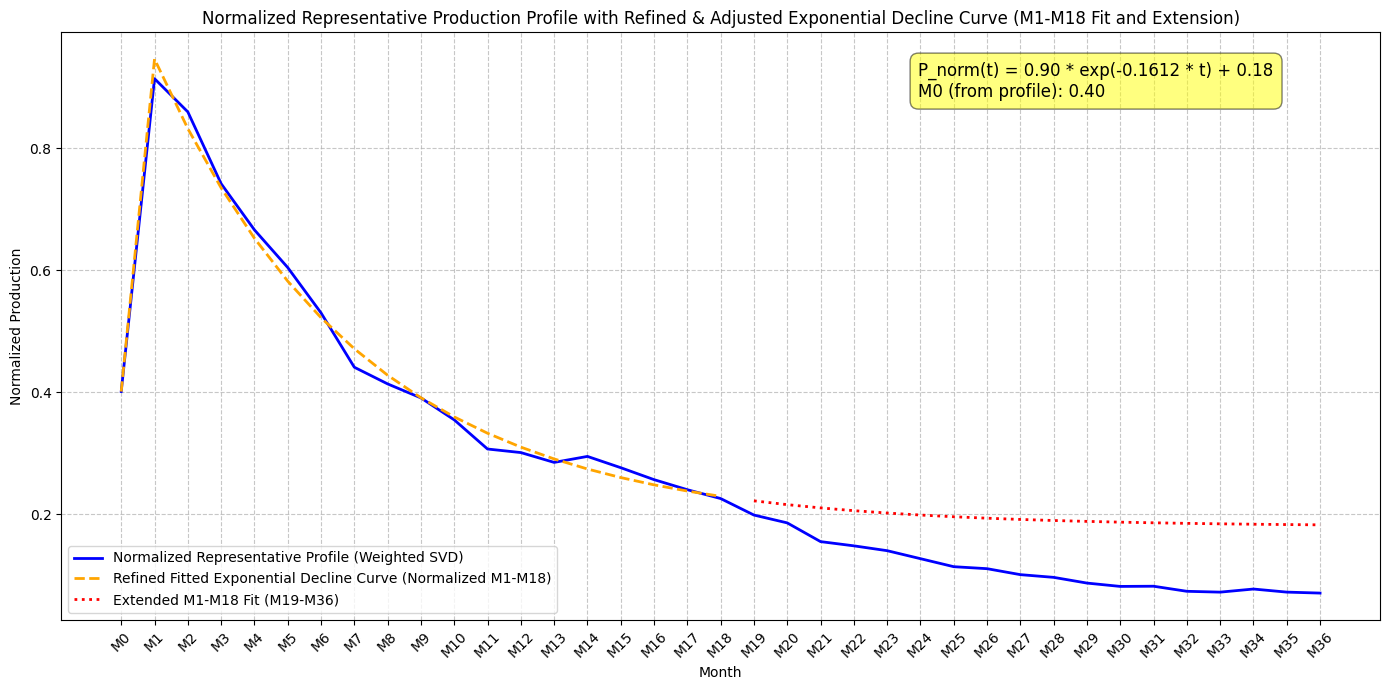

In [11]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

# Define the exponential decline function (same as before)
def exponential_decline(t, A, B, C):
    return A * np.exp(-B * t) + C

# Prepare data for fitting, excluding M0 and limiting to M1-M18
x_data_m1_m18 = np.arange(1, 19) # Months from 1 to 18
y_data_m1_m18 = representative_df_normalized['Normalized Representative Production (Weighted SVD)'].iloc[1:19].values

# Initial guess for the parameters (A, B, C) for the M1-M18 data
initial_guess_m1_m18 = [y_data_m1_m18[0], 0.1, y_data_m1_m18[-1]]

# Perform the curve fitting on the refined normalized data (M1 to M18)
try:
    params_m1_m18, covariance_m1_m18 = curve_fit(
        exponential_decline, x_data_m1_m18, y_data_m1_m18,
        p0=initial_guess_m1_m18, maxfev=5000
    )
    A_fit_m1_m18, B_fit_m1_m18, C_fit_m1_m18 = params_m1_m18

    print(f"Refined Fitted Parameters (Normalized M1-M18): A={A_fit_m1_m18:.2f}, B={B_fit_m1_m18:.4f}, C={C_fit_m1_m18:.2f}")

    # Generate the fitted curve data for M1 to M18
    fitted_curve_data_m1_m18 = exponential_decline(x_data_m1_m18, A_fit_m1_m18, B_fit_m1_m18, C_fit_m1_m18)

    # Use the M0 value from the Normalized Representative Profile directly
    m0_estimated_normalized_m1_m18 = representative_df_normalized.loc['M0', 'Normalized Representative Production (Weighted SVD)']

    # Combine M0 estimated with the fitted data for M1-M18
    # Now, calculate the extension for M19-M36 using the same fit parameters
    x_data_extension = np.arange(19, len(production_cols))
    fitted_curve_extension = exponential_decline(x_data_extension, A_fit_m1_m18, B_fit_m1_m18, C_fit_m1_m18)

    # Create a full curve with M0, M1-M18 fitted values, and M19-M36 extension
    full_fitted_curve_m1_m18_extended = np.insert(fitted_curve_data_m1_m18, 0, m0_estimated_normalized_m1_m18)
    full_fitted_curve_m1_m18_extended = np.concatenate((full_fitted_curve_m1_m18_extended, fitted_curve_extension))

    # Create an array of NaNs for the part of the original fit that is not covered by the M1-M18 fit
    fitted_curve_m1_m18_only_for_plot = np.insert(fitted_curve_data_m1_m18, 0, m0_estimated_normalized_m1_m18)
    fitted_curve_m1_m18_only_for_plot = np.pad(fitted_curve_m1_m18_only_for_plot, (0, len(production_cols) - len(fitted_curve_m1_m18_only_for_plot)), 'constant', constant_values=np.nan)

    # Create an array of NaNs for the M0-M18 part for the extension plot
    fitted_curve_extension_only_for_plot = np.pad(fitted_curve_extension, (len(x_data_m1_m18) + 1, 0), 'constant', constant_values=np.nan)

    # Plot the original normalized representative profile and the new, refined fitted curve
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=representative_df_normalized.index, y=representative_df_normalized['Normalized Representative Production (Weighted SVD)'], label='Normalized Representative Profile (Weighted SVD)', color='blue', linewidth=2)
    sns.lineplot(x=representative_df_normalized.index, y=fitted_curve_m1_m18_only_for_plot, label='Refined Fitted Exponential Decline Curve (Normalized M1-M18)', color='orange', linestyle='--', linewidth=2)
    sns.lineplot(x=representative_df_normalized.index, y=fitted_curve_extension_only_for_plot, label='Extended M1-M18 Fit (M19-M36)', color='red', linestyle=':', linewidth=2)

    plt.title('Normalized Representative Production Profile with Refined & Adjusted Exponential Decline Curve (M1-M18 Fit and Extension)')
    plt.xlabel('Month')
    plt.ylabel('Normalized Production')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()

    # Add equation and parameters to the plot, including M0
    equation_text_normalized_m1_m18 = (
            f"P_norm(t) = {A_fit_m1_m18:.2f} * exp(-{B_fit_m1_m18:.4f} * t) + {C_fit_m1_m18:.2f}\n"
            f"M0 (from profile): {m0_estimated_normalized_m1_m18:.2f}"
        )
    plt.text(0.65, 0.95, equation_text_normalized_m1_m18, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting refined normalized curve (M1-M18): {e}. Check initial guess or data.")

### Storing Highest Production Values for Distribution Modeling

To model the uncertainty in new well production, we need the distribution of the highest production values from the existing wells. Below, we store these values in a DataFrame for further analysis.

In [12]:
# Store the highest production values for each well
max_production_data = pd.DataFrame({
    'WellID': df['WellID'],
    'Highest_Production': highest_production_per_well
})

print("Highest Production Values per Well:")
display(max_production_data)


Highest Production Values per Well:


,WellID,Highest_Production
0,A1,1122.0
1,A2,640.0
2,A3,461.0
3,A4,598.0
4,A5,502.0
5,A6,1608.0
6,A7,893.0
7,A8,1561.0
8,A9,900.0
9,A10,1147.0


### Probability Distribution of Highest Production Values

Now, let's visualize the distribution of the `Highest_Production` column. This distribution will be crucial for modeling uncertainty in new well production. We will use a histogram and a Kernel Density Estimate (KDE) plot to understand its shape, and calculate key descriptive statistics.

Descriptive Statistics for Highest Production:


,Highest_Production
count,60.000000
mean,1950.083333
std,1333.858050
min,5.000000
25%,949.500000
50%,1550.000000
75%,3091.500000
max,5425.000000


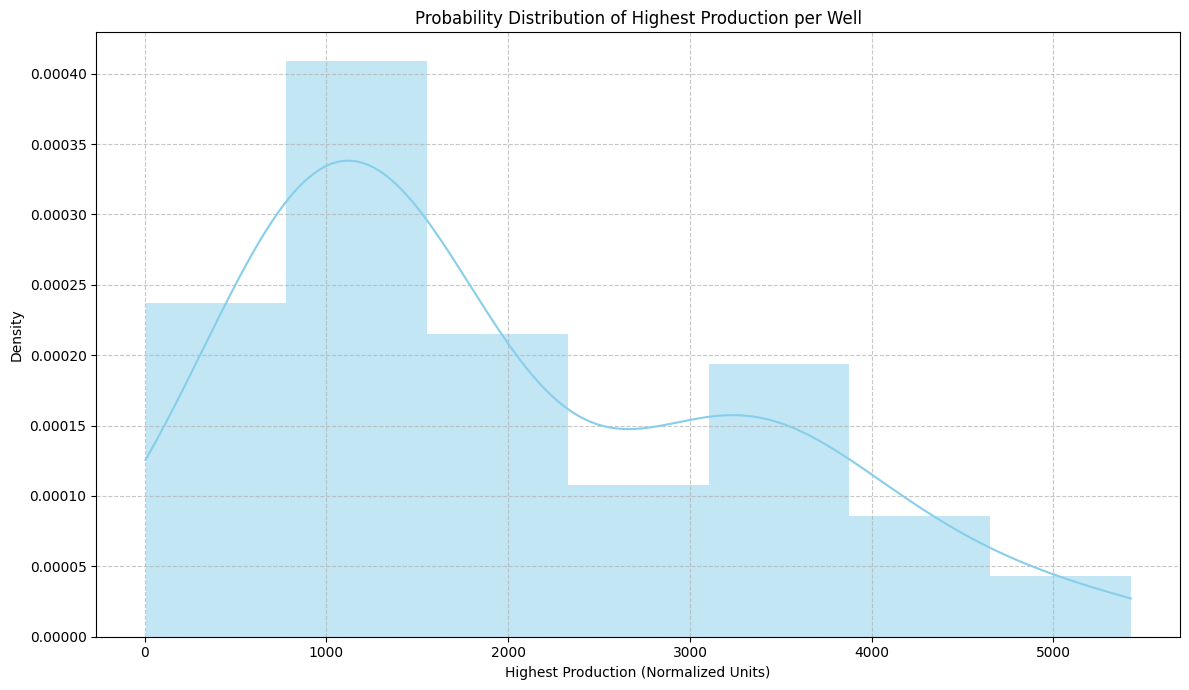

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate descriptive statistics
production_stats = max_production_data['Highest_Production'].describe()
print("Descriptive Statistics for Highest Production:")
display(production_stats)

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.histplot(max_production_data['Highest_Production'], kde=True, color='skyblue', stat='density', linewidth=0)
plt.title('Probability Distribution of Highest Production per Well')
plt.xlabel('Highest Production (Normalized Units)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
